# Accelerated SGS Validation

This notebook validates `SGS_forward_sweep_acc` and `SGS_backward_sweep_acc` against the baseline coupled SGS sweeps in `main_solver.py`.

The goal is to show that the accelerated solver reaches the same converged solution, residual level, and MMS error norms as the baseline solver before using it in longer Phase III Reynolds-number or kappa studies.

In [1]:
from pathlib import Path
import contextlib
import io
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


if Path.cwd().name != "start-code" and (Path.cwd() / "start-code").exists():
    os.chdir(Path.cwd() / "start-code")

print(f"Working directory: {Path.cwd()}")


# Keep these small at first. Enable the 33x33 case after the 17x17 cases pass.
VALIDATION_CASES = [
    {"name": "mms_17_re10", "nodes": 17, "imms": 1, "Re": 10.0, "toler": 1e-10, "enabled": True},
    {"name": "cavity_17_re10", "nodes": 17, "imms": 0, "Re": 10.0, "toler": 1e-10, "enabled": True},
    {"name": "mms_33_re10", "nodes": 33, "imms": 1, "Re": 10.0, "toler": 1e-10, "enabled": False},
]

FIELD_ABS_TOL = 1e-5
NORM_REL_TOL = 1e-3
CONV_FACTOR_TOL = 10.0
EQUATIONS = ["p", "u", "v"]

Working directory: /Users/windy/mae4100-courseproject2/start-code


In [2]:
def apply_replacements(source, replacements, solver_path):
    for old, new in replacements.items():
        if old not in source:
            raise RuntimeError(f"Could not find expected setting in {solver_path}: {old}")
        source = source.replace(old, new, 1)
    return source


def build_solver_source(case, accelerated):
    solver_path = Path("main_solver.py")
    source = solver_path.read_text()

    replacements = {
        "imax = 9               # Number of points in the x-direction (use odd numbers only)":
            f"imax = {case['nodes']:<15}# Number of points in the x-direction (use odd numbers only)",
        "jmax = 9               # Number of points in the y-direction (use odd numbers only)":
            f"jmax = {case['nodes']:<15}# Number of points in the y-direction (use odd numbers only)",
        "iterout = 5000         # Number of time steps between solution output":
            "iterout = 100000000    # Number of time steps between solution output",
        "imms = 0               # Manufactured solution flag: 1 for manuf. sol., 0 otherwise":
            f"imms = {case['imms']:<15}# Manufactured solution flag: 1 for manuf. sol., 0 otherwise",
        "toler = 1e-10          # Tolerance for iterative residual convergence":
            f"toler = {case['toler']:<13.1e}# Tolerance for iterative residual convergence",
        "Re = 10.0              # Reynolds number = rho*Uinf*L/rmu":
            f"Re = {case['Re']:<16g}# Reynolds number = rho*Uinf*L/rmu",
        "vectorize = False":
            "vectorize = True",
    }
    source = apply_replacements(source, replacements, solver_path)

    if accelerated:
        source = apply_replacements(
            source,
            {
                "u = SGS_forward_sweep(u, uold, dt, s, rho, rhoinv, dx, dy, rkappa, rmu, vel2ref, artviscx, artviscy)":
                    "u = SGS_forward_sweep_acc(u, uold, dt, s, rho, rhoinv, dx, dy, rkappa, rmu, vel2ref, artviscx, artviscy)",
                "u = SGS_backward_sweep(u, uold, dt, s, rho, rhoinv, dx, dy, rkappa, rmu, vel2ref, artviscx, artviscy)":
                    "u = SGS_backward_sweep_acc(u, uold, dt, s, rho, rhoinv, dx, dy, rkappa, rmu, vel2ref, artviscx, artviscy)",
            },
            solver_path,
        )

    return source, solver_path


def run_solver_case(case, accelerated):
    source, solver_path = build_solver_source(case, accelerated)
    namespace = {
        "__file__": str(solver_path.resolve()),
        "__name__": "__main__",
    }

    start = time.perf_counter()
    with contextlib.redirect_stdout(io.StringIO()) as captured_output:
        exec(compile(source, str(solver_path), "exec"), namespace)
    elapsed = time.perf_counter() - start
    plt.close("all")

    return {
        "case": case["name"],
        "implementation": "accelerated" if accelerated else "baseline",
        "nodes": case["nodes"],
        "imms": case["imms"],
        "Re": case["Re"],
        "elapsed_sec": elapsed,
        "iterations": int(namespace["n"]),
        "converged": bool(namespace["isConverged"]),
        "conv": float(namespace["conv"]),
        "res": namespace["res"].copy(),
        "u": namespace["u"].copy(),
        "rL1norm": namespace["rL1norm"].copy(),
        "rL2norm": namespace["rL2norm"].copy(),
        "rLinfnorm": namespace["rLinfnorm"].copy(),
        "captured_output": captured_output.getvalue(),
    }


def summarize_run(result):
    return {
        "case": result["case"],
        "implementation": result["implementation"],
        "nodes": f"{result['nodes']}x{result['nodes']}",
        "imms": result["imms"],
        "Re": result["Re"],
        "iterations": result["iterations"],
        "converged": result["converged"],
        "conv": result["conv"],
        "elapsed_sec": result["elapsed_sec"],
        "L2_p": result["rL2norm"][0],
        "L2_u": result["rL2norm"][1],
        "L2_v": result["rL2norm"][2],
    }


def compare_pair(baseline, accelerated):
    field_abs = np.max(np.abs(baseline["u"] - accelerated["u"]), axis=(0, 1))
    field_scale = np.maximum(np.max(np.abs(baseline["u"]), axis=(0, 1)), 1e-14)
    field_rel = field_abs / field_scale

    l2_abs = np.abs(baseline["rL2norm"] - accelerated["rL2norm"])
    l2_scale = np.maximum(np.abs(baseline["rL2norm"]), 1e-14)
    l2_rel = l2_abs / l2_scale

    conv_limit = CONV_FACTOR_TOL * max(baseline["conv"], 1e-14)
    passes_field = bool(np.all(field_abs < FIELD_ABS_TOL))
    passes_norms = bool(np.all(l2_rel < NORM_REL_TOL))
    passes_conv = bool(accelerated["conv"] <= conv_limit)

    return {
        "case": baseline["case"],
        "nodes": f"{baseline['nodes']}x{baseline['nodes']}",
        "baseline_iter": baseline["iterations"],
        "accelerated_iter": accelerated["iterations"],
        "baseline_conv": baseline["conv"],
        "accelerated_conv": accelerated["conv"],
        "speedup_excluding_jit_caution": baseline["elapsed_sec"] / accelerated["elapsed_sec"],
        "max_abs_p": field_abs[0],
        "max_abs_u": field_abs[1],
        "max_abs_v": field_abs[2],
        "max_rel_p": field_rel[0],
        "max_rel_u": field_rel[1],
        "max_rel_v": field_rel[2],
        "max_rel_L2_norm_diff": np.max(l2_rel),
        "passes_field_tol": passes_field,
        "passes_norm_tol": passes_norms,
        "passes_conv_tol": passes_conv,
        "passes_all": passes_field and passes_norms and passes_conv,
    }

In [3]:
enabled_cases = [case for case in VALIDATION_CASES if case["enabled"]]
results = []

for case in enabled_cases:
    print(f"\nRunning baseline SGS: {case['name']} ({case['nodes']}x{case['nodes']})")
    baseline = run_solver_case(case, accelerated=False)
    print(f"  baseline: iterations={baseline['iterations']}, conv={baseline['conv']:.3e}, time={baseline['elapsed_sec']:.2f} s")

    print(f"Running accelerated SGS: {case['name']} ({case['nodes']}x{case['nodes']})")
    accelerated = run_solver_case(case, accelerated=True)
    print(f"  accelerated: iterations={accelerated['iterations']}, conv={accelerated['conv']:.3e}, time={accelerated['elapsed_sec']:.2f} s")

    results.extend([baseline, accelerated])

summary_table = pd.DataFrame([summarize_run(result) for result in results])
comparison_table = pd.DataFrame([
    compare_pair(
        next(result for result in results if result["case"] == case["name"] and result["implementation"] == "baseline"),
        next(result for result in results if result["case"] == case["name"] and result["implementation"] == "accelerated"),
    )
    for case in enabled_cases
])

print("\nRun summary:")
display(summary_table)

print("\nBaseline vs accelerated comparison:")
display(comparison_table)


Running baseline SGS: mms_17_re10 (17x17)
  baseline: iterations=1633, conv=9.955e-11, time=4.31 s
Running accelerated SGS: mms_17_re10 (17x17)
  accelerated: iterations=1633, conv=9.955e-11, time=10.02 s

Running baseline SGS: cavity_17_re10 (17x17)
  baseline: iterations=1916, conv=9.878e-11, time=4.83 s
Running accelerated SGS: cavity_17_re10 (17x17)
  accelerated: iterations=1916, conv=9.878e-11, time=10.57 s

Run summary:


,case,implementation,nodes,imms,Re,iterations,converged,conv,elapsed_sec,L2_p,L2_u,L2_v
0,mms_17_re10,baseline,17x17,1,10.0,1633,True,9.954551e-11,4.314713,0.000361,0.000081,0.000031
1,mms_17_re10,accelerated,17x17,1,10.0,1633,True,9.954551e-11,10.022514,0.000361,0.000081,0.000031
2,cavity_17_re10,baseline,17x17,0,10.0,1916,True,9.878143e-11,4.831802,0.000000,0.000000,0.000000
3,cavity_17_re10,accelerated,17x17,0,10.0,1916,True,9.878143e-11,10.570569,0.000000,0.000000,0.000000



Baseline vs accelerated comparison:


,case,nodes,baseline_iter,accelerated_iter,baseline_conv,accelerated_conv,speedup_excluding_jit_caution,max_abs_p,max_abs_u,max_abs_v,max_rel_p,max_rel_u,max_rel_v,max_rel_L2_norm_diff,passes_field_tol,passes_norm_tol,passes_conv_tol,passes_all
0,mms_17_re10,17x17,1633,1633,9.954551e-11,9.954551e-11,0.430502,6.661338e-16,1.110223e-16,1.110223e-16,6.520614e-16,1.372188e-16,1.549148e-16,8.307916e-14,True,True,True,True
1,cavity_17_re10,17x17,1916,1916,9.878143e-11,9.878143e-11,0.457099,8.881784e-16,1.110223e-16,1.110223e-16,2.116623e-16,1.110223e-16,3.300494e-16,0.000000e+00,True,True,True,True


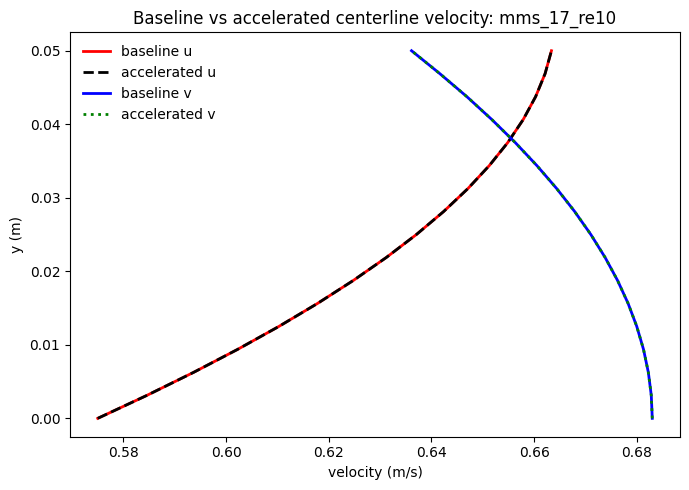

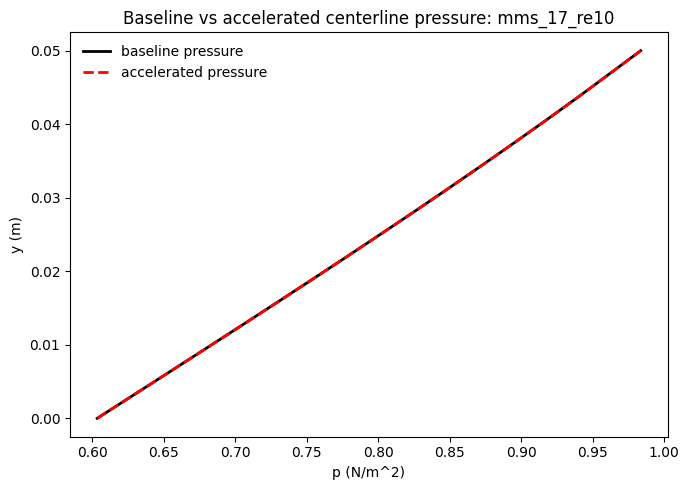

In [4]:
if results:
    plot_case = enabled_cases[0]["name"]
    baseline = next(result for result in results if result["case"] == plot_case and result["implementation"] == "baseline")
    accelerated = next(result for result in results if result["case"] == plot_case and result["implementation"] == "accelerated")

    i_mid = (baseline["nodes"] - 1) // 2
    y = np.linspace(0.0, 0.05, baseline["nodes"])

    plt.figure(figsize=(7, 5))
    plt.plot(baseline["u"][i_mid, :, 1], y, "-r", linewidth=2, label="baseline u")
    plt.plot(accelerated["u"][i_mid, :, 1], y, "--k", linewidth=2, label="accelerated u")
    plt.plot(baseline["u"][i_mid, :, 2], y, "-b", linewidth=2, label="baseline v")
    plt.plot(accelerated["u"][i_mid, :, 2], y, ":g", linewidth=2, label="accelerated v")
    plt.xlabel("velocity (m/s)")
    plt.ylabel("y (m)")
    plt.title(f"Baseline vs accelerated centerline velocity: {plot_case}")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(baseline["u"][i_mid, :, 0], y, "-k", linewidth=2, label="baseline pressure")
    plt.plot(accelerated["u"][i_mid, :, 0], y, "--r", linewidth=2, label="accelerated pressure")
    plt.xlabel("p (N/m^2)")
    plt.ylabel("y (m)")
    plt.title(f"Baseline vs accelerated centerline pressure: {plot_case}")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()